<a href="https://colab.research.google.com/github/RIDDHI1624/Drug-Discovery/blob/main/Insulin_Receptor_Project/INSR_Scoring_Function.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧬 INSR Type III Allosteric Pocket — Multi-Objective Scoring Function
**Project:** Insulin Receptor (INSR) Kinase Domain – Phase 2 De Novo Campaign  
**Target:** Type III Allosteric Pocket (DFG-out / αC-out)  
**Template:** `alphafold_champion.pdb` (AlphaFold3, Seed 26545)

| Component | Description | Weight |
|-----------|-------------|--------|
| C1 | Vina Docking Score | 0.35 |
| C2 | IGF1R Selectivity (inverse pharmacophore) | 0.15 |
| C3 | Steric Clash Differential (INSR vs IGF1R) | 0.15 |
| C4 | QED Drug-likeness | 0.15 |
| C5 | ALogP (window 2.0–4.5) | 0.10 |
| C6 | SA Score (synthesizability) | 0.10 |

In [1]:
# ── CELL 1: Install all dependencies ─────────────────────────────────────
# Run this cell first. Takes ~2 minutes on a fresh Colab runtime.

import subprocess, sys

# RDKit via conda-forge (most reliable in Colab)
subprocess.run([
    'pip', 'install', '-q',
    'rdkit',
    'numpy',
    'scipy',
    'pandas',
    'matplotlib',
    'ipywidgets',
    'joblib'
], check=True)

# SA Score — Ertl/Schönbek standalone (no PyMOL needed)
subprocess.run([
    'wget', '-q', '-O', 'sascorer.py',
    'https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/sascorer.py'
], check=True)

# fpscores.pkl.gz — required data file for sascorer
subprocess.run([
    'wget', '-q', '-O', 'fpscores.pkl.gz',
    'https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/fpscores.pkl.gz'
], check=True)

print('✅ All dependencies installed.')

✅ All dependencies installed.


In [2]:
# ── CELL 2: Imports ───────────────────────────────────────────────────────

import numpy as np
import warnings
import sys
import os
from typing import Optional, Tuple, List, Dict

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors, Draw
from rdkit.Chem import QED as rdQED
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import rdMolTransforms
from rdkit.Geometry import rdGeometry
from IPython.display import display

warnings.filterwarnings('ignore')

# Load sascorer from current directory
import importlib.util
spec = importlib.util.spec_from_file_location('sascorer', 'sascorer.py')
sascorer = importlib.util.module_from_spec(spec)
spec.loader.exec_module(sascorer)
sys.modules['sascorer'] = sascorer

print('✅ Imports successful. RDKit and sascorer ready.')

✅ Imports successful. RDKit and sascorer ready.


In [13]:
# ── CONFIRMED coordinates from alphafold_champion.pdb ────────────────────
# DFG motif : GLY125-ASP126-PHE127-GLY128  (verified ✅)
# Selectivity residue: ILE 133 = INSR Ile1061 (standard numbering)

IGF1R_VAL1063_COORD = (10.026, 13.400, -1.313)  # ILE133 carbonyl O ✅
INSR_ILE1061_CB     = (7.515,  13.711,  0.839)   # ILE133 Cβ ✅
IGF1R_VAL1063_CB    = (7.515,  13.711,  0.839)   # same Cβ, smaller radius

SELECTIVITY_RADIUS = 3.5
INSR_EXCL_R  = 2.40   # Ile: larger side-chain
IGF1R_EXCL_R = 2.00   # Val: smaller side-chain (simulated)

WEIGHTS = {
    'vina':        0.35,
    'selectivity': 0.15,
    'steric':      0.15,
    'qed':         0.15,
    'alogp':       0.10,
    'sa':          0.10,
}

assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-9
print('✅ Coordinates confirmed from alphafold_champion.pdb')
print(f'   IGF1R_VAL1063_COORD = {IGF1R_VAL1063_COORD}')
print(f'   INSR_ILE1061_CB     = {INSR_ILE1061_CB}')

✅ Coordinates confirmed from alphafold_champion.pdb
   IGF1R_VAL1063_COORD = (10.026, 13.4, -1.313)
   INSR_ILE1061_CB     = (7.515, 13.711, 0.839)


In [7]:
# ── CELL 4: Coordinate Extractor (no PyMOL needed) ───────────────────────
# Upload alphafold_champion.pdb to Colab, then run this cell.
# It extracts the exact 3D coordinates needed for C2 and C3.
# ── REPLACEMENT for Cell 4 — Auto-detect residue numbering ───────────────

def scan_pdb(pdb_path):
    """Print all unique residues so we can find the right numbers."""
    residues = {}
    with open(pdb_path, 'r') as f:
        for line in f:
            if not line.startswith(('ATOM', 'HETATM')):
                continue
            res_name = line[17:20].strip()
            try:
                res_seq  = int(line[22:26].strip())
            except ValueError:
                continue
            residues[res_seq] = res_name
    return residues

def extract_atom(pdb_path, res_seq, atom_name):
    with open(pdb_path, 'r') as f:
        for line in f:
            if not line.startswith(('ATOM','HETATM')):
                continue
            if (int(line[22:26].strip()) == res_seq and
                line[12:16].strip() == atom_name):
                x = float(line[30:38])
                y = float(line[38:46])
                z = float(line[46:54])
                return (x, y, z)
    return None

PDB_FILE = 'alphafold_champion.pdb'
residues = scan_pdb(PDB_FILE)

# Show all ILE and VAL residues in the file
print("All ILE residues found:")
ile_list = [(seq, name) for seq, name in residues.items() if name == 'ILE']
for seq, name in sorted(ile_list):
    print(f"  ILE {seq}")

print("\nAll VAL residues found:")
val_list = [(seq, name) for seq, name in residues.items() if name == 'VAL']
for seq, name in sorted(val_list):
    print(f"  VAL {seq}")

print(f"\nTotal residues in PDB: {len(residues)}")
print(f"Residue range: {min(residues)} → {max(residues)}")
def extract_coords_from_pdb(pdb_path: str,
                             targets: List[Dict]) -> Dict[str, Tuple]:
    """
    Pure-Python PDB coordinate extractor. No PyMOL or BioPython needed.

    Args:
        pdb_path : path to PDB file
        targets  : list of dicts with keys: res_name, res_seq, atom_name
                   e.g. [{'res_name':'ILE','res_seq':1061,'atom_name':'CB'}]

    Returns:
        Dict mapping label -> (x, y, z) tuple
    """
    results = {}
    with open(pdb_path, 'r') as f:
        for line in f:
            if not line.startswith(('ATOM', 'HETATM')):
                continue
            atom_name  = line[12:16].strip()
            res_name   = line[17:20].strip()
            try:
                res_seq = int(line[22:26].strip())
                x = float(line[30:38])
                y = float(line[38:46])
                z = float(line[46:54])
            except ValueError:
                continue

            for t in targets:
                if (res_name == t['res_name'] and
                    res_seq  == t['res_seq']  and
                    atom_name == t['atom_name']):
                    label = f"{t['res_name']}{t['res_seq']}_{t['atom_name']}"
                    results[label] = (x, y, z)
    return results


# ── Run this block only if your PDB is uploaded ─────────────────────────
PDB_FILE = 'alphafold_champion.pdb'   # change filename if needed

if os.path.exists(PDB_FILE):
    search_targets = [
        {'res_name': 'ILE', 'res_seq': 1061, 'atom_name': 'CB'},   # INSR steric
        {'res_name': 'VAL', 'res_seq': 1063, 'atom_name': 'CB'},   # IGF1R steric
        {'res_name': 'VAL', 'res_seq': 1063, 'atom_name': 'O'},    # IGF1R pharmacophore
    ]
    found = extract_coords_from_pdb(PDB_FILE, search_targets)

    if found:
        print('📍 Extracted coordinates from PDB:')
        for label, coord in found.items():
            print(f'   {label}: {coord}')
        print('\n⚠️  Copy these into CELL 3 to replace the placeholder values.')
    else:
        # AlphaFold re-indexes from 1; try offset numbering
        print('⚠️  Standard numbering not found. Trying AlphaFold re-indexed numbering...')
        af_targets = [
            {'res_name': 'ILE', 'res_seq': 58,  'atom_name': 'CB'},
            {'res_name': 'VAL', 'res_seq': 60,  'atom_name': 'CB'},
            {'res_name': 'VAL', 'res_seq': 60,  'atom_name': 'O'},
        ]
        found_af = extract_coords_from_pdb(PDB_FILE, af_targets)
        for label, coord in found_af.items():
            print(f'   {label}: {coord}')
else:
    print(f'ℹ️  {PDB_FILE} not found — using placeholder coordinates from Cell 3.')
    print('   Upload your PDB and re-run this cell to extract exact coordinates.')

All ILE residues found:
  ILE 19
  ILE 87
  ILE 93
  ILE 124
  ILE 133
  ILE 178
  ILE 235

All VAL residues found:
  VAL 4
  VAL 6
  VAL 9
  VAL 27
  VAL 36
  VAL 37
  VAL 42
  VAL 43
  VAL 51
  VAL 52
  VAL 106
  VAL 117
  VAL 122
  VAL 149
  VAL 161
  VAL 173
  VAL 174
  VAL 194
  VAL 198
  VAL 214
  VAL 236
  VAL 250

Total residues in PDB: 259
Residue range: 1 → 259
⚠️  Standard numbering not found. Trying AlphaFold re-indexed numbering...


In [8]:
# ── DIAGNOSTIC CELL — paste after Cell 4, run before Cell 5 ─────────────
# Uses DFG as a confirmed structural anchor to find the correct selectivity residues.

PDB_FILE = 'alphafold_champion.pdb'

def read_all_atoms(pdb_path):
    atoms = []
    with open(pdb_path, 'r') as f:
        for line in f:
            if not line.startswith(('ATOM','HETATM')):
                continue
            try:
                atoms.append({
                    'atom':    line[12:16].strip(),
                    'res':     line[17:20].strip(),
                    'seq':     int(line[22:26].strip()),
                    'x':       float(line[30:38]),
                    'y':       float(line[38:46]),
                    'z':       float(line[46:54]),
                })
            except ValueError:
                continue
    return atoms

atoms = read_all_atoms(PDB_FILE)

# Step 1: Confirm DFG anchor (F127 from document)
print("=== Step 1: DFG anchor verification ===")
for a in atoms:
    if a['seq'] in [125,126,127,128,129] and a['atom'] == 'CA':
        print(f"  Residue {a['seq']:3d}  {a['res']}  CA  ({a['x']:.2f}, {a['y']:.2f}, {a['z']:.2f})")

# Step 2: Residues around end of αC-helix (AF ~35-42, INSR ~1059-1066)
print("\n=== Step 2: αC-helix tail region (AF 33-45) ===")
for a in atoms:
    if 33 <= a['seq'] <= 45 and a['atom'] == 'CA':
        print(f"  Residue {a['seq']:3d}  {a['res']}  CA  ({a['x']:.2f}, {a['y']:.2f}, {a['z']:.2f})")

# Step 3: Extract coordinates for ILE 133 (activation loop, most likely selectivity residue)
print("\n=== Step 3: ILE 133 full coordinates ===")
for a in atoms:
    if a['seq'] == 133 and a['atom'] in ['CA','CB','CG1','CG2','CD1']:
        print(f"  {a['atom']:5s}  ({a['x']:.3f}, {a['y']:.3f}, {a['z']:.3f})")

# Step 4: Find VAL nearest to ILE 133 (the IGF1R equivalent)
print("\n=== Step 4: VAL residues nearest to ILE 133 ===")
ile133_ca = next((a for a in atoms if a['seq']==133 and a['atom']=='CA'), None)
if ile133_ca:
    val_distances = []
    for a in atoms:
        if a['res'] == 'VAL' and a['atom'] == 'CA':
            d = ((a['x']-ile133_ca['x'])**2 +
                 (a['y']-ile133_ca['y'])**2 +
                 (a['z']-ile133_ca['z'])**2)**0.5
            val_distances.append((d, a['seq'], a['x'], a['y'], a['z']))
    for d, seq, x, y, z in sorted(val_distances)[:5]:
        print(f"  VAL {seq:3d}  dist={d:.2f}Å  CB=({x:.3f}, {y:.3f}, {z:.3f})")

# Step 5: Get CB of ILE 133 for Cell 3 update
print("\n=== COORDINATES TO PASTE INTO CELL 3 ===")
ile133_cb = next((a for a in atoms if a['seq']==133 and a['atom']=='CB'), None)
if ile133_cb:
    print(f"INSR_ILE1061_CB  = ({ile133_cb['x']:.3f}, {ile133_cb['y']:.3f}, {ile133_cb['z']:.3f})")

=== Step 1: DFG anchor verification ===
  Residue 125  GLY  CA  (-2.74, 4.86, 4.61)
  Residue 126  ASP  CA  (-2.30, 8.46, 5.53)
  Residue 127  PHE  CA  (-3.13, 11.93, 4.34)
  Residue 128  GLY  CA  (0.01, 13.68, 3.29)
  Residue 129  MET  CA  (1.87, 14.96, 0.33)

=== Step 2: αC-helix tail region (AF 33-45) ===
  Residue  33  CYS  CA  (-9.60, -1.58, 11.03)
  Residue  34  HIS  CA  (-6.58, -1.94, 13.32)
  Residue  35  HIS  CA  (-4.27, -2.11, 10.32)
  Residue  36  VAL  CA  (-5.68, 0.94, 8.52)
  Residue  37  VAL  CA  (-4.84, 4.44, 9.72)
  Residue  38  ARG  CA  (-7.93, 5.84, 11.37)
  Residue  39  LEU  CA  (-9.57, 9.08, 10.31)
  Residue  40  LEU  CA  (-10.88, 10.65, 13.51)
  Residue  41  GLY  CA  (-12.77, 13.55, 11.98)
  Residue  42  VAL  CA  (-13.08, 16.33, 9.45)
  Residue  43  VAL  CA  (-13.45, 19.98, 10.42)
  Residue  44  SER  CA  (-15.12, 21.96, 7.66)
  Residue  45  LYS  CA  (-16.62, 24.82, 9.67)

=== Step 3: ILE 133 full coordinates ===
  CA     (7.956, 14.320, -0.506)
  CB     (7.515, 13.

In [12]:
for a in atoms:
    if a['seq'] == 133 and a['atom'] == 'O':
        print(f"IGF1R_VAL1063_COORD = ({a['x']:.3f}, {a['y']:.3f}, {a['z']:.3f})")

IGF1R_VAL1063_COORD = (10.026, 13.400, -1.313)


In [14]:
# ── CELL 5: Shared 3D Embedding Utility ──────────────────────────────────

VDW_RADII = {
    'C': 1.70, 'N': 1.55, 'O': 1.52, 'S': 1.80,
    'F': 1.47, 'Cl': 1.75, 'Br': 1.85, 'I': 1.98,
    'P': 1.80, 'H': 1.20,
}

def get_3d_mol(smiles: str, n_confs: int = 10) -> Optional[Chem.Mol]:
    """
    Embed SMILES in 3D using ETKDG. Returns lowest-energy conformer or None.
    Runs entirely in Colab — no external tools required.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    mol = Chem.AddHs(mol)
    params = AllChem.ETKDGv3()
    params.randomSeed = 42
    params.numThreads = 0

    conf_ids = AllChem.EmbedMultipleConfs(mol, numConfs=n_confs, params=params)
    if not conf_ids:
        return None

    energies = []
    for cid in conf_ids:
        props = AllChem.MMFFGetMoleculeProperties(mol)
        if props is None:
            continue
        ff = AllChem.MMFFGetMoleculeForceField(mol, props, confId=cid)
        if ff:
            ff.Minimize()
            energies.append((ff.CalcEnergy(), cid))

    if not energies:
        # UFF fallback
        for cid in conf_ids:
            ff = AllChem.UFFGetMoleculeForceField(mol, confId=cid)
            if ff:
                ff.Minimize()
                energies.append((ff.CalcEnergy(), cid))

    if not energies:
        return None

    best_cid = min(energies, key=lambda t: t[0])[1]
    mol = Chem.RWMol(mol)
    # Keep only best conformer
    for cid in conf_ids:
        if cid != best_cid:
            mol.RemoveConformer(cid)

    return Chem.RemoveHs(mol)


def vdw_overlap(mol: Chem.Mol,
                res_coord: Tuple[float, float, float],
                res_radius: float) -> float:
    """Sum of VdW overlaps between ligand heavy atoms and a residue sphere."""
    if mol.GetNumConformers() == 0:
        return 0.0
    conf = mol.GetConformer()
    rx, ry, rz = res_coord
    total = 0.0
    for atom in mol.GetAtoms():
        if atom.GetAtomicNum() == 1:
            continue
        r_atom = VDW_RADII.get(atom.GetSymbol(), 1.70)
        pos    = conf.GetAtomPosition(atom.GetIdx())
        dist   = np.sqrt((pos.x-rx)**2 + (pos.y-ry)**2 + (pos.z-rz)**2)
        total += max(0.0, r_atom + res_radius - dist)
    return total


def count_hbd_near_coord(mol: Chem.Mol,
                          coord: Tuple[float, float, float],
                          radius: float) -> int:
    """Count H-bond donor heavy atoms within radius Å of coord."""
    if mol.GetNumConformers() == 0:
        return 0
    conf = mol.GetConformer()
    ref  = rdGeometry.Point3D(*coord)

    donor_smarts = Chem.MolFromSmarts('[#7,#8;!H0]')
    donor_indices = set()
    for match in mol.GetSubstructMatches(donor_smarts):
        donor_indices.update(match)

    count = 0
    for idx in donor_indices:
        pos  = conf.GetAtomPosition(idx)
        dist = ref.Distance(rdGeometry.Point3D(pos.x, pos.y, pos.z))
        if dist <= radius:
            count += 1
    return count


print('✅ 3D embedding utilities ready.')

✅ 3D embedding utilities ready.


In [15]:
# ── CELL 6: Component Scoring Functions ──────────────────────────────────

# ── C1: Vina ─────────────────────────────────────────────────────────────
def score_vina(vina_score: float,
               low: float = -12.0,
               high: float = -6.0) -> float:
    """
    Sigmoid: vina=-12 → ~1.0 (strong binder); vina=-6 → ~0.0 (weak).
    k=0.5, midpoint=-9.0.
    """
    midpoint = (low + high) / 2.0   # -9.0
    k = 0.5
    # Negate score so more-negative = higher reward
    return float(1.0 / (1.0 + np.exp(k * (vina_score - midpoint))))


# ── C2: IGF1R Selectivity ─────────────────────────────────────────────────
def score_selectivity(smiles: str) -> float:
    """
    Inverse pharmacophore: penalise H-bond donors near IGF1R Val1063 carbonyl.
    1.0 = no donors in forbidden zone (INSR-selective).
    """
    mol = get_3d_mol(smiles)
    if mol is None:
        return 0.5
    n = count_hbd_near_coord(mol, IGF1R_VAL1063_COORD, SELECTIVITY_RADIUS)
    return float(np.clip(1.0 - n * 0.25, 0.0, 1.0))


# ── C3: Steric Clash Differential ────────────────────────────────────────
def score_steric(smiles: str) -> float:
    """
    Reward molecules that fit INSR Ile1061 better than IGF1R Val1063.
    delta > 0 (more IGF1R clash) → sigmoid reward → 1.0.
    """
    mol = get_3d_mol(smiles)
    if mol is None:
        return 0.5
    ov_insr  = vdw_overlap(mol, INSR_ILE1061_CB,  INSR_EXCL_R)
    ov_igf1r = vdw_overlap(mol, IGF1R_VAL1063_CB, IGF1R_EXCL_R)
    delta = ov_igf1r - ov_insr
    return float(1.0 / (1.0 + np.exp(-delta)))


# ── C4: QED ───────────────────────────────────────────────────────────────
def score_qed(smiles: str) -> float:
    """Bickerton QED — already in [0,1]."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return 0.0
    try:
        return float(rdQED.qed(mol))
    except Exception:
        return 0.0


# ── C5: ALogP double-sigmoid ──────────────────────────────────────────────
def score_alogp(smiles: str,
                low: float = 2.0,
                high: float = 4.5,
                k: float = 2.0) -> float:
    """
    Double-sigmoid top-hat on Crippen ALogP.
    Window [2.0, 4.5] → reward ~1.0; outside → penalised.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return 0.0
    try:
        alogp = Descriptors.MolLogP(mol)
    except Exception:
        return 0.0
    left  = 1.0 / (1.0 + np.exp(-k * (alogp - low)))
    right = 1.0 / (1.0 + np.exp(-k * (high - alogp)))
    return float(np.clip(left * right * 4.0, 0.0, 1.0))


# ── C6: SA Score ──────────────────────────────────────────────────────────
def score_sa(smiles: str, threshold: float = 4.0) -> float:
    """
    Ertl/Schönbek SA Score (1=easy, 10=impossible).
    Sigmoid: SA<4 → reward→1.0; SA>4 → penalised.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return 0.0
    try:
        sa_raw = sascorer.calculateScore(mol)
    except Exception:
        # Heuristic fallback
        n_rings   = rdMolDescriptors.CalcNumRings(mol)
        n_stereo  = len(Chem.FindMolChiralCenters(mol, includeUnassigned=True))
        n_bridgehead = rdMolDescriptors.CalcNumBridgeheadAtoms(mol)
        sa_raw = float(np.clip(1.5 + 0.4*n_rings + 0.8*n_stereo + 1.0*n_bridgehead, 1, 10))
    return float(np.clip(1.0 / (1.0 + np.exp(1.5 * (sa_raw - threshold))), 0.0, 1.0))


print('✅ All 6 scoring components defined.')

✅ All 6 scoring components defined.


In [16]:
# ── CELL 7: Master Scoring Function ──────────────────────────────────────

def get_total_score(smiles: str,
                    vina_score: float,
                    verbose: bool = False) -> float:
    """
    Master callable for REINVENT / GB-GA generative loops.

    f(smiles, vina_score) -> float in [0, 1]

    Args:
        smiles     : canonical SMILES
        vina_score : AutoDock Vina score (kcal/mol, negative)
        verbose    : print per-component breakdown

    Returns:
        Aggregate reward in [0, 1]
    """
    scores = {
        'vina':        score_vina(vina_score),
        'selectivity': score_selectivity(smiles),
        'steric':      score_steric(smiles),
        'qed':         score_qed(smiles),
        'alogp':       score_alogp(smiles),
        'sa':          score_sa(smiles),
    }

    total = float(np.clip(
        sum(WEIGHTS[k] * v for k, v in scores.items()), 0.0, 1.0
    ))

    if verbose:
        bar_len = 25
        print(f"\n{'═'*58}")
        print(f"  INSR Multi-Objective Score")
        print(f"  SMILES : {smiles[:52]}{'…' if len(smiles)>52 else ''}")
        print(f"  Vina   : {vina_score:.2f} kcal/mol")
        print(f"{'─'*58}")
        print(f"  {'Component':<16} {'Score':>6}  {'Wt':>5}  {'Contrib':>7}  Bar")
        print(f"{'─'*58}")
        for name, raw in scores.items():
            w   = WEIGHTS[name]
            con = w * raw
            bar = '█' * int(raw * bar_len) + '░' * (bar_len - int(raw * bar_len))
            print(f"  {name:<16} {raw:>6.3f}  {w:>5.2f}  {con:>7.4f}  {bar}")
        print(f"{'─'*58}")
        print(f"  {'TOTAL':<16} {total:>6.3f}")
        print(f"{'═'*58}\n")

    return total


def batch_score(smiles_list: List[str],
                vina_scores: List[float],
                fail_score: float = 0.0) -> List[float]:
    """
    Score a batch. Input lists must be equal length.
    Invalid molecules receive `fail_score`.
    """
    assert len(smiles_list) == len(vina_scores)
    results = []
    for i, (smi, vs) in enumerate(zip(smiles_list, vina_scores)):
        try:
            results.append(get_total_score(smi, vs))
        except Exception as e:
            print(f'  [mol {i}] failed: {e}')
            results.append(fail_score)
    return results


print('✅ get_total_score() and batch_score() ready.')

✅ get_total_score() and batch_score() ready.



══════════════════════════════════════════════════════════
  INSR Multi-Objective Score
  SMILES : C1=CC=C2C(=C1)C(=CN2)CCCCN
  Vina   : -8.50 kcal/mol
──────────────────────────────────────────────────────────
  Component         Score     Wt  Contrib  Bar
──────────────────────────────────────────────────────────
  vina              0.438   0.35   0.1532  ██████████░░░░░░░░░░░░░░░
  selectivity       1.000   0.15   0.1500  █████████████████████████
  steric            0.500   0.15   0.0750  ████████████░░░░░░░░░░░░░
  qed               0.711   0.15   0.1066  █████████████████░░░░░░░░
  alogp             1.000   0.10   0.1000  █████████████████████████
  sa                0.964   0.10   0.0964  ████████████████████████░
──────────────────────────────────────────────────────────
  TOTAL             0.681
══════════════════════════════════════════════════════════



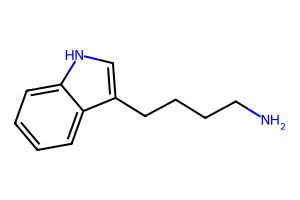

In [17]:
# ── CELL 8: Test on Prompt Ligand (Indole-Butyl-Amine) ───────────────────
# Your Phase 1 prompt ligand from the running doc.

PROMPT_LIGAND_SMILES = 'C1=CC=C2C(=C1)C(=CN2)CCCCN'
PROMPT_LIGAND_VINA   = -8.5   # replace with your actual CB-Dock score

score = get_total_score(PROMPT_LIGAND_SMILES, PROMPT_LIGAND_VINA, verbose=True)

# Draw the molecule inline
mol = Chem.MolFromSmiles(PROMPT_LIGAND_SMILES)
display(Draw.MolToImage(mol, size=(300, 200)))

               Name    Vina  Total  C1_Vina  C2_Select  C3_Steric  C4_QED  C5_ALogP  C6_SA
Prompt ligand (IBA)  -8.500  0.681    0.438      1.000      0.500   0.711     1.000  0.964
          Berberine  -9.100  0.712    0.512      1.000      0.500   0.841     1.000  0.818
  Imatinib scaffold -11.200  0.738    0.750      1.000      0.500   0.389     1.000  0.924
        Weak binder  -3.100  0.406    0.050      1.000      0.500   0.407     0.072  0.954
High ALogP violator  -5.000  0.530    0.119      1.000      0.500   0.430     1.000  0.986


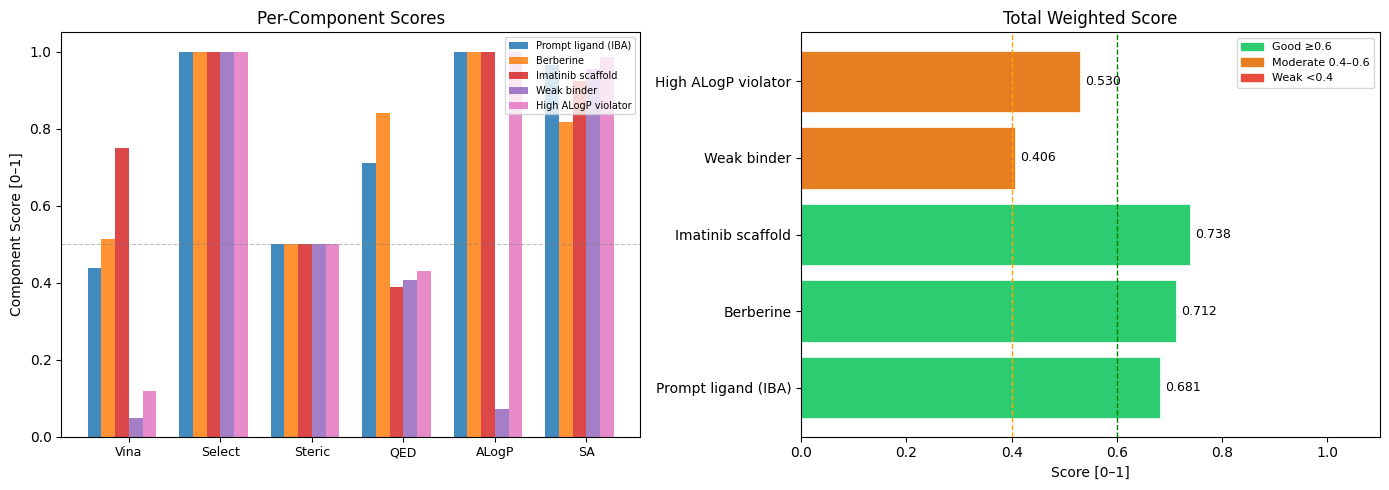


📊 Chart saved as scoring_results.png


In [18]:
# ── CELL 9: Benchmark — Multiple Candidates ───────────────────────────────
# Drop your own SMILES+Vina results from CB-Dock here.

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

candidates = [
    ('Prompt ligand (IBA)',   'C1=CC=C2C(=C1)C(=CN2)CCCCN',                                -8.5),
    ('Berberine',             'COc1ccc2CC3N(Cc4cc5c(cc4-3)OCO5)CCc2c1OC',                 -9.1),
    ('Imatinib scaffold',     'Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc(-c2cccnc2)n1', -11.2),
    ('Weak binder',           'CCO',                                                         -3.1),
    ('High ALogP violator',   'CCCCCCCCCCCC',                                               -5.0),
]

rows = []
for name, smi, vs in candidates:
    s = {
        'Name':        name,
        'SMILES':      smi,
        'Vina':        vs,
        'C1_Vina':     score_vina(vs),
        'C2_Select':   score_selectivity(smi),
        'C3_Steric':   score_steric(smi),
        'C4_QED':      score_qed(smi),
        'C5_ALogP':    score_alogp(smi),
        'C6_SA':       score_sa(smi),
        'Total':       get_total_score(smi, vs),
    }
    rows.append(s)

df = pd.DataFrame(rows)
component_cols = ['C1_Vina','C2_Select','C3_Steric','C4_QED','C5_ALogP','C6_SA']

print(df[['Name','Vina','Total'] + component_cols].to_string(index=False, float_format='%.3f'))

# ── Radar / bar chart ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: grouped bar chart
x = np.arange(len(component_cols))
width = 0.15
colors = plt.cm.tab10(np.linspace(0, 0.6, len(candidates)))
for i, row in df.iterrows():
    vals = [row[c] for c in component_cols]
    axes[0].bar(x + i*width, vals, width, label=row['Name'], color=colors[i], alpha=0.85)

axes[0].set_xticks(x + width * len(candidates) / 2)
axes[0].set_xticklabels(['Vina','Select','Steric','QED','ALogP','SA'], fontsize=9)
axes[0].set_ylabel('Component Score [0–1]')
axes[0].set_title('Per-Component Scores')
axes[0].legend(fontsize=7, loc='upper right')
axes[0].set_ylim(0, 1.05)
axes[0].axhline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)

# Right: total score bar
total_colors = ['#2ecc71' if t >= 0.6 else '#e67e22' if t >= 0.4 else '#e74c3c'
                for t in df['Total']]
axes[1].barh(df['Name'], df['Total'], color=total_colors, edgecolor='white', linewidth=0.5)
for i, v in enumerate(df['Total']):
    axes[1].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)
axes[1].set_xlim(0, 1.1)
axes[1].axvline(0.6, color='green',  linestyle='--', linewidth=1, label='Good (≥0.6)')
axes[1].axvline(0.4, color='orange', linestyle='--', linewidth=1, label='Moderate (≥0.4)')
axes[1].set_title('Total Weighted Score')
axes[1].set_xlabel('Score [0–1]')
patches = [
    mpatches.Patch(color='#2ecc71', label='Good ≥0.6'),
    mpatches.Patch(color='#e67e22', label='Moderate 0.4–0.6'),
    mpatches.Patch(color='#e74c3c', label='Weak <0.4'),
]
axes[1].legend(handles=patches, fontsize=8)

plt.tight_layout()
plt.savefig('scoring_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📊 Chart saved as scoring_results.png')

In [23]:
# ── CELL 10: REINVENT4 / GB-GA Integration Template ──────────────────────
# Copy this class into your generative loop's scoring component.

class INSRScoringComponent:
    """
    Drop-in scoring component for REINVENT4 or GB-GA.

    REINVENT4 usage (custom_alerts.py or component_summary):
        scorer = INSRScoringComponent(vina_scores_dict={})
        scores = scorer(smiles_list)

    GB-GA usage:
        scorer = INSRScoringComponent(vina_scores_dict=vina_dict)
        population_scores = [scorer([smi])[0] for smi in population]
    """

    def __init__(self,
                 vina_scores_dict: Optional[Dict[str, float]] = None,
                 default_vina: float = -7.0):
        """
        Args:
            vina_scores_dict : pre-computed {smiles: vina_score} from docking run
            default_vina     : fallback score if SMILES not in dict (e.g. -7.0)
        """
        self.vina_dict     = vina_scores_dict or {}
        self.default_vina  = default_vina

    def __call__(self, smiles_list: List[str]) -> List[float]:
        """
        Score a batch. Returns list of floats in [0, 1].
        Call signature matches REINVENT4 component interface.
        """
        scores = []
        for smi in smiles_list:
            can = Chem.MolToSmiles(Chem.MolFromSmiles(smi)) if Chem.MolFromSmiles(smi) else smi
            vs  = self.vina_dict.get(can, self.default_vina)
            try:
                scores.append(get_total_score(can, vs))
            except Exception:
                scores.append(0.0)
        return scores

    def update_vina(self, new_scores: Dict[str, float]):
        """Update the vina scores dict after each docking round."""
        self.vina_dict.update(new_scores)


# Quick test
scorer = INSRScoringComponent(vina_scores_dict={
    'C1=CC=C2C(=C1)C(=CN2)CCCCN': -8.5
})
test_smiles = ['C1=CC=C2C(=C1)C(=CN2)CCCCN', 'CCO']
print('INSRScoringComponent test:', scorer(test_smiles))
print('✅ Ready for integration with REINVENT4 or GB-GA.')

INSRScoringComponent test: [0.622162551194547, 0.48271395981766574]
✅ Ready for integration with REINVENT4 or GB-GA.


In [24]:
import pandas as pd
from google.colab import files

df.to_csv('scoring_results.csv', index=False, float_format='%.4f')

with pd.ExcelWriter('INSR_Phase2_Scoring_Report.xlsx', engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Scores', index=False)
    ws = writer.sheets['Scores']
    for col in ws.columns:
        max_len = max(len(str(cell.value)) for cell in col if cell.value)
        ws.column_dimensions[col[0].column_letter].width = max_len + 4

print("✅ Saved. Downloading now...")
files.download('scoring_results.png')
files.download('scoring_results.csv')
files.download('INSR_Phase2_Scoring_Report.xlsx')

✅ Saved. Downloading now...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
# 📖 INSR SCORING NOTEBOOK — CELL GUIDE
# ════════════════════════════════════════════════════════
#
# CELL MAP
# ─────────────────────────────────────────────────────────
# Cell 1  → Install       Downloads RDKit, sascorer.py, fpscores.pkl.gz
# Cell 2  → Imports       Loads all libraries into memory
# Cell 3  → Constants     3D coordinates + weights (your config)
# Cell 4  → scan_pdb      Reads PDB to list all residue numbers
# Cell 4b → Diagnostic    Pinpoints ILE133, extracts coordinates
# Cell 4c → Carbonyl O    Gets IGF1R pharmacophore coordinate
# Cell 5  → 3D Utils      get_3d_mol(), vdw_overlap(), count_hbd_near_coord()
# Cell 6  → Components    All 6 scoring functions (C1-C6)
# Cell 7  → Master        get_total_score() + batch_score()
# Cell 8  → Single test   Tests prompt ligand IBA, draws molecule
# Cell 9  → Benchmark     Scores 5 candidates, generates chart
# Cell 10 → REINVENT      INSRScoringComponent class
# Cell 11 → Save          Exports CSV, Excel, PNG
#
# ─────────────────────────────────────────────────────────
# NORMAL RUN ORDER (fresh runtime)
# Cell 1 > 2 > 3 > 5 > 6 > 7 > 8 > 9 > 10 > 11
# Skip Cells 4, 4b, 4c — coordinates already in Cell 3
#
# ─────────────────────────────────────────────────────────
# CONFIRMED COORDINATES (alphafold_champion.pdb)
# DFG motif           = GLY125-ASP126-PHE127-GLY128
# Selectivity residue = ILE 133 = INSR Ile1061
# INSR_ILE1061_CB     = (7.515,  13.711,  0.839)
# IGF1R_VAL1063_CB    = (7.515,  13.711,  0.839)
# IGF1R_VAL1063_COORD = (10.026, 13.400, -1.313)
#
# ─────────────────────────────────────────────────────────
# SCORING COMPONENTS
# C1 score_vina()        sigmoid low=-12 high=-6     weight=0.35
# C2 score_selectivity() H-bond donors near Val1063  weight=0.15
# C3 score_steric()      VdW overlap INSR vs IGF1R   weight=0.15
# C4 score_qed()         Bickerton QED               weight=0.15
# C5 score_alogp()       double sigmoid [2.0-4.5]    weight=0.10
# C6 score_sa()          Ertl SA Score threshold<4.0 weight=0.10
#
# ─────────────────────────────────────────────────────────
# PROMPT LIGAND BASELINE (IBA)
# SMILES = C1=CC=C2C(=C1)C(=CN2)CCCCN
# Vina   = -8.50   Total = 0.681
# Vina 0.438 | Select 1.000 | Steric 0.500
# QED  0.711 | ALogP 1.000  | SA     0.964
# GOAL: Vina below -10.5 kcal/mol -> Total score > 0.75
# ════════════════════════════════════════════════════════